# Investigating a Deployed ML Model via API

- Author: Alex Heyert
- Date: 2026-07
- API: ML Penguin Predictor
- Endpoint: https://ml-penguin-predictor.onrender.com/predict
- Target: species

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## Section 1. Project Setup and Imports

In [10]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Any  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import plotly.express as px

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M07", level="DEBUG")
log_header(LOG, "M07")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  requests:     {version('requests')}")
LOG.info(f"  plotly {version('plotly')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# === Section 1e. GLOBAL CONSTANTS ===

# CUSTOM: update this URL if you deploy your own model.
API_URL: str = "https://ml-06-serving.onrender.com/predict"
LOG.info(f"API endpoint: {API_URL}")

2026-08-13 21:16:34 | INFO | M07 | === RUN START ===
2026-08-13 21:16:34 | INFO | M07 | project=M07
2026-08-13 21:16:34 | INFO | M07 | repo_dir=ml-07-applied
2026-08-13 21:16:34 | INFO | M07 | python=3.14.7
2026-08-13 21:16:34 | INFO | M07 | os=Linux 6.8.0-1052-azure
2026-08-13 21:16:34 | INFO | M07 | shell=bash
2026-08-13 21:16:34 | INFO | M07 | cwd=notebooks
2026-08-13 21:16:34 | INFO | M07 | github_actions=False
2026-08-13 21:16:34 | INFO | M07 | Confirming installation:
2026-08-13 21:16:34 | INFO | M07 |   python:       3.14.7
2026-08-13 21:16:34 | INFO | M07 |   pandas:       3.0.5
2026-08-13 21:16:34 | INFO | M07 |   numpy:        2.5.2
2026-08-13 21:16:34 | INFO | M07 |   matplotlib:   3.11.1
2026-08-13 21:16:34 | INFO | M07 |   seaborn:      0.13.2
2026-08-13 21:16:34 | INFO | M07 |   requests:     2.34.2
2026-08-13 21:16:34 | INFO | M07 |   plotly 6.9.0
2026-08-13 21:16:34 | INFO | M07 | API endpoint: https://ml-06-serving.onrender.com/predict


## Section 2. Baseline Predictions

```text
ANALYST CHOICE
Before investigating, confirm the API returns expected results for
known inputs. If these baseline calls fail, the investigation cannot proceed.
```

In [11]:
# === Section 2. Baseline Predictions ===


def predict(payload: dict[str, Any]) -> str:
    """Send a payload to the prediction API and return the predicted species.

    WHY: A single reusable function keeps all API calls consistent.
    Any change to the endpoint or headers only needs to happen here.

    Args:
        payload: dict of feature name -> value.

    Returns:
        Predicted species string, or an error message string.
    """
    try:
        response = requests.post(API_URL, json=payload, timeout=30)
        response.raise_for_status()
        return str(response.json().get("prediction", "NO_PREDICTION_KEY"))
    except requests.exceptions.Timeout:
        return "TIMEOUT (server may be sleeping - try again)"
    except requests.exceptions.RequestException as exc:
        return f"ERROR: {exc}"


# One known example per species from the penguins dataset.
BASELINES: list[dict[str, Any]] = [
    {
        "bill_length_mm": 39.1,
        "bill_depth_mm": 18.7,
        "flipper_length_mm": 181,
        "body_mass_g": 3750,
    },
    {
        "bill_length_mm": 46.5,
        "bill_depth_mm": 17.9,
        "flipper_length_mm": 192,
        "body_mass_g": 3500,
    },
    {
        "bill_length_mm": 46.1,
        "bill_depth_mm": 13.2,
        "flipper_length_mm": 211,
        "body_mass_g": 4500,
    },
    {"bill_length_mm": 45,
     "bill_depth_mm": 16,
     "flipper_length_mm": 205,
     "body_mass_g": 4000}
]
EXPECTED: list[str] = ["Adelie", "Chinstrap", "Gentoo", "MedianSurprise"]

LOG.info("Baseline predictions:")
for payload, expected in zip(BASELINES, EXPECTED, strict=True):
    result = predict(payload)
    match = "OK" if result == expected else "MISMATCH"
    LOG.info(result)
    LOG.info(f"  expected={expected:<10} got={result:<10} [{match}]")

2026-08-13 21:16:34 | INFO | M07 | Baseline predictions:


2026-08-13 21:16:34 | INFO | M07 | Adelie
2026-08-13 21:16:34 | INFO | M07 |   expected=Adelie     got=Adelie     [OK]
2026-08-13 21:16:35 | INFO | M07 | Chinstrap
2026-08-13 21:16:35 | INFO | M07 |   expected=Chinstrap  got=Chinstrap  [OK]
2026-08-13 21:16:35 | INFO | M07 | Gentoo
2026-08-13 21:16:35 | INFO | M07 |   expected=Gentoo     got=Gentoo     [OK]
2026-08-13 21:16:35 | INFO | M07 | Chinstrap
2026-08-13 21:16:35 | INFO | M07 |   expected=MedianSurprise got=Chinstrap  [MISMATCH]


### Analyst Judgment: Baseline Results Summary

**Record your observations here:**

- All baseline predictions met expected values, the 4th one that I added wasn't designed to match a specific species so much as be more broud it could be interpreted as another species with tuning.
- The API works well, but usually requires a second run after "waking" the render instance.

## Section 3. Feature Sensitivity

```text
ANALYST CHOICE
Vary one feature at a time while holding others fixed.
Observe where the prediction changes. That boundary is the model's
decision for that feature. Decide which features matter most.
```

2026-08-13 21:16:38 | INFO | M07 | bill_length_mm sweep:
2026-08-13 21:16:38 | INFO | M07 |  bill_length_mm prediction
      30.000000     Adelie
      33.333333     Adelie
      36.666667     Adelie
      40.000000     Adelie
      43.333333     Gentoo
      46.666667  Chinstrap
      50.000000  Chinstrap
      53.333333  Chinstrap
      56.666667  Chinstrap
      60.000000  Chinstrap


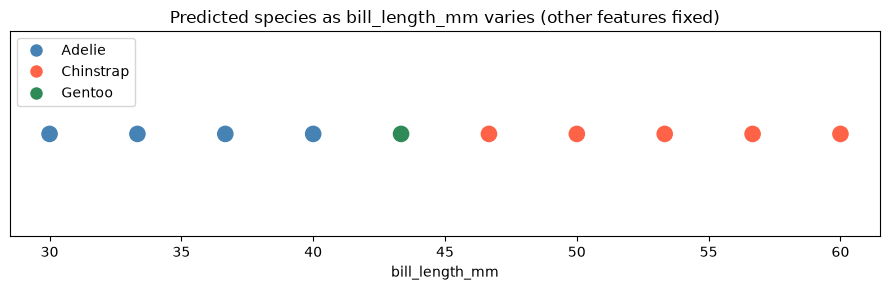

2026-08-13 21:16:38 | INFO | M07 | ANALYST CHOICE: Where does the prediction shift and does that match your expectation?


In [12]:
# === Section 3. Feature Sensitivity ===


def sweep_feature(
    base: dict[str, Any],
    feature: str,
    values: list[float],
) -> pd.DataFrame:
    """Vary one feature across a range and collect predictions.

    WHY: Holding all other features fixed isolates the effect of one input.
    This is the simplest way to probe a black-box model.

    Args:
        base: baseline payload with all four features set.
        feature: the feature name to vary.
        values: list of values to try for that feature.

    Returns:
        DataFrame with columns [feature, 'prediction'].
    """
    rows = []
    for v in values:
        payload = {**base, feature: v}
        rows.append({feature: v, "prediction": predict(payload)})
    return pd.DataFrame(rows)


# Use the Adelie baseline and sweep bill_length_mm.
BASE: dict[str, Any] = BASELINES[3] ###Adjust so not so biased to Adelie
bill_lengths = list(np.linspace(30, 60, 10))
df_sweep = sweep_feature(BASE, "bill_length_mm", bill_lengths)

LOG.info("bill_length_mm sweep:")
LOG.info(df_sweep.to_string(index=False))

# Plot prediction vs feature value.
species_order = ["Adelie", "Chinstrap", "Gentoo"]
color_map = {"Adelie": "steelblue", "Chinstrap": "tomato", "Gentoo": "seagreen"}
colors = df_sweep["prediction"].map(color_map).fillna("gray")

plt.figure(figsize=(9, 3))
plt.scatter(df_sweep["bill_length_mm"], [1] * len(df_sweep), c=colors, s=120)
plt.xlabel("bill_length_mm")
plt.yticks([])
plt.title("Predicted species as bill_length_mm varies (other features fixed)")
handles = [
    plt.Line2D(  # pyright: ignore[reportPrivateImportUsage]
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[s],
        markersize=10,
        label=s,
    )
    for s in species_order
]
plt.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: Where does the prediction shift and does that match your expectation?"
)

### Analyst Judgment: bill_length_mm Sensitivity

**Summarize your findings:**

- The prediction first shift away from Adelie at 45 mm. 
- It briefly shows Gentoo, then continues to Chinstrap
- The 3d plot helps explain this (and past analysis of the penguins dataset helped me pick good ranges)

2026-08-13 21:16:42 | INFO | M07 | flipper_length_mm sweep:
2026-08-13 21:16:42 | INFO | M07 |  flipper_length_mm prediction
        160.000000     Adelie
        166.315789     Adelie
        172.631579     Adelie
        178.947368     Adelie
        185.263158     Adelie
        191.578947     Adelie
        197.894737     Adelie
        204.210526     Adelie
        210.526316     Adelie
        216.842105     Adelie
        223.157895     Adelie
        229.473684     Adelie
        235.789474     Adelie
        242.105263     Adelie
        248.421053     Adelie
        254.736842     Adelie
        261.052632     Adelie
        267.368421     Adelie
        273.684211     Adelie
        280.000000     Adelie


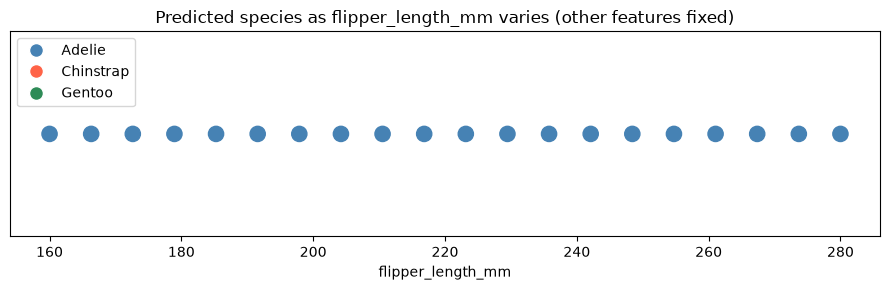

In [13]:
# Use the Adelie baseline and sweep flipper_length_mm.
BASE: dict[str, Any] = BASELINES[0]
flipper_lengths = list(np.linspace(160, 280, 20))
df_sweep = sweep_feature(BASE, "flipper_length_mm", flipper_lengths)

LOG.info("flipper_length_mm sweep:")
LOG.info(df_sweep.to_string(index=False))

# Plot prediction vs feature value.
species_order = ["Adelie", "Chinstrap", "Gentoo"]
color_map = {"Adelie": "steelblue", "Chinstrap": "tomato", "Gentoo": "seagreen"}
colors = df_sweep["prediction"].map(color_map).fillna("gray")

plt.figure(figsize=(9, 3))
plt.scatter(df_sweep["flipper_length_mm"], [1] * len(df_sweep), c=colors, s=120)
plt.xlabel("flipper_length_mm")
plt.yticks([])
plt.title("Predicted species as flipper_length_mm varies (other features fixed)")
handles = [
    plt.Line2D(  # pyright: ignore[reportPrivateImportUsage]
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[s],
        markersize=10,
        label=s,
    )
    for s in species_order
]
plt.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.show()

### Analyst Judgment: flipper_length_mm Sensitivity

**Summarize your findings:**

- Flipper length only shows Adelie, despite trying to choose a netrual baseline model.
- Bill length has a more obvious boundary, so the model likely finds that feature to be more significant.

## Section 4. Prediction Grid

```text
ANALYST CHOICE
Vary two features together and visualize the 2D decision surface.
Choose the two features you think matter most based on Section 3.
```

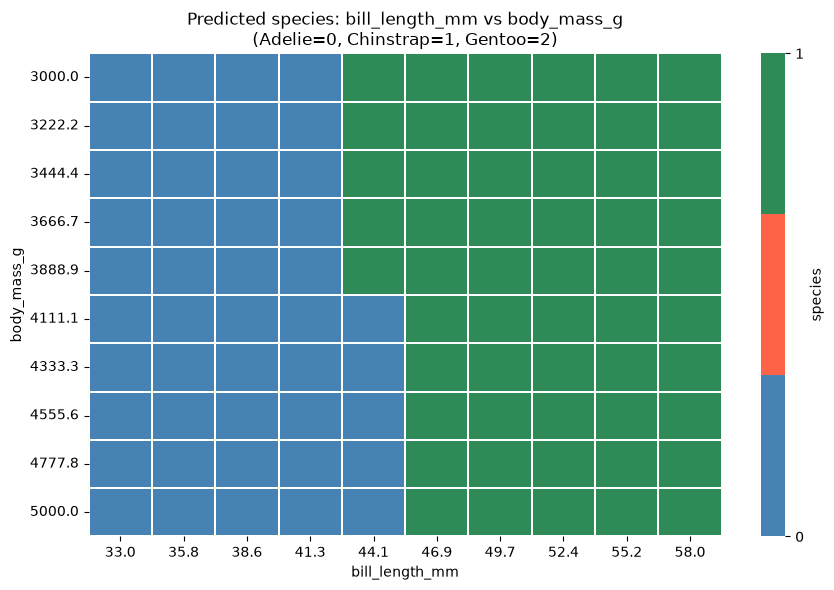

2026-08-13 21:17:09 | INFO | M07 | ANALYST CHOICE: What does the boundary shape tell you about the model?


In [14]:
# === Section 4. Prediction Grid ===

# CUSTOM: adjust ranges based on your investigation in Section 3.
bill_length_values = list(np.linspace(33, 58, 10))
#flipper_length_values = list(np.linspace(170, 230, 10))
body_mass_values = list(np.linspace(3000, 5000, 10))

rows = []
for bl in bill_length_values:
    for bm in body_mass_values:
        payload = {**BASE, "bill_length_mm": bl, "body_mass_g": bm}
        rows.append(
            {
                "bill_length_mm": round(bl, 1),
                "body_mass_g": round(bm, 1),
                "prediction": predict(payload),
            }
        )

df_grid = pd.DataFrame(rows)
species_to_int = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
df_grid["species_int"] = df_grid["prediction"].map(species_to_int).fillna(-1)

pivot = df_grid.pivot(
    index="body_mass_g",
    columns="bill_length_mm",
    values="species_int",
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot,
    cmap=["steelblue", "tomato", "seagreen"],
    linewidths=0.3,
    cbar_kws={"ticks": [0, 1, 2], "label": "species"},
)
plt.title(
    "Predicted species: bill_length_mm vs body_mass_g\n(Adelie=0, Chinstrap=1, Gentoo=2)"
)
plt.tight_layout()
plt.show()

LOG.info("ANALYST CHOICE: What does the boundary shape tell you about the model?")

### Analyst Judgment: 2D Decision Surface

**Summarize the boundary patterns:**

- The decision boundary seems to be entirely based upon bill_length, and not all 3 species are captured by this. Body mass does not seem to be a very helpful feature differentiator. 

In [15]:
#Sweep 3 features, keep body mass the same
fixed_body_mass = 4300 #g
#sweep 3 features
bill_length_values = list(np.linspace(32, 59, 6))
flipper_length_values = list(np.linspace(172, 231, 6))
bill_depth_values = list(np.linspace(13, 21, 6))
results = []
for bl in bill_length_values:
    for fl in flipper_length_values:
        for bd in bill_depth_values:
            payload = {
                "bill_length_mm": bl,
                "flipper_length_mm": fl,
                "bill_depth_mm": bd,
                "body_mass_g": fixed_body_mass
            }
            results.append({
                "bill_length_mm": bl,
                "flipper_length_mm": fl,
                "bill_depth_mm": bd,
                "prediction": predict(payload)
            })
results_df = pd.DataFrame(results)




In [16]:
plt.figure()
fig = px.scatter_3d(
    results_df, 
    x='bill_length_mm', 
    y='flipper_length_mm', 
    z='bill_depth_mm',
    color='prediction',
    title="3D Decision Surface (body_mass fixed)"
)
fig.write_html("../docs/images/fixed_body_mass_3d_graph.html")
#fig.write_image("../docs/images/fixed_body_mass_3d_graph.png")
fig.show()

<Figure size 640x480 with 0 Axes>

## Analyst Insights
The 3d chart finally shows us a wide range of predictions and includes all 3 species. In the future I would probably start with a plot like this then look at each feature in more detail. This would not neccesarily work for a 20 feature influenced ML model, but for our 4 feature input trained ML model, it's a great way to see the decision boundaries. 

## Section 5. Edge Cases

In [17]:
# === Section 5. Edge Cases ===

edge_cases: list[tuple[str, dict[str, Any]]] = [
    (
        "missing feature",
        {"bill_length_mm": 39.1, "bill_depth_mm": 18.7, "flipper_length_mm": 181},
    ),
    (
        "extreme bill length",
        {
            "bill_length_mm": 1.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "very large bill",
        {
            "bill_length_mm": 999.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "negative value",
        {
            "bill_length_mm": -10.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "zero body mass",
        {
            "bill_length_mm": 39.1,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 0,
        },
    ),
]

LOG.info("Edge case results:")
for label, payload in edge_cases:
    result = predict(payload)
    LOG.info(f"  {label:<22} -> {result}")

LOG.info("ANALYST CHOICE: Which edge cases were handled cleanly and which were not?")

2026-08-13 21:18:03 | INFO | M07 | Edge case results:
2026-08-13 21:18:03 | INFO | M07 |   missing feature        -> ERROR: 422 Client Error: Unprocessable Entity for url: https://ml-06-serving.onrender.com/predict
2026-08-13 21:18:03 | INFO | M07 |   extreme bill length    -> Adelie
2026-08-13 21:18:03 | INFO | M07 |   very large bill        -> Chinstrap
2026-08-13 21:18:03 | INFO | M07 |   negative value         -> Adelie
2026-08-13 21:18:04 | INFO | M07 |   zero body mass         -> Adelie
2026-08-13 21:18:04 | INFO | M07 | ANALYST CHOICE: Which edge cases were handled cleanly and which were not?


### Analyst Judgment: Edge Case Robustness

**Assess API robustness:**

- The only edge case that was handled properly was one missing required information. To make the API more robust, stricter limits should be imposed when type checking. No negative or 0 values should return a prediction and maximum values might be useful.

## Section 6. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [18]:
# === Section 6. Summary ===


def summarize() -> None:
    """Record what was investigated and the judgment still owed."""
    LOG.info("========================")
    LOG.info("SUMMARY")
    LOG.info("========================")
    LOG.info(f"API endpoint: {API_URL}")
    LOG.info("========================")


summarize()

2026-08-13 21:18:04 | INFO | M07 | ========================
2026-08-13 21:18:04 | INFO | M07 | SUMMARY
2026-08-13 21:18:04 | INFO | M07 | ========================
2026-08-13 21:18:04 | INFO | M07 | API endpoint: https://ml-06-serving.onrender.com/predict
2026-08-13 21:18:04 | INFO | M07 | ========================


I think the next steps would be to apply this concept to a more complex model. Since the model is hosted on a "free" site, number of queries were slightly limited, but enough was accomplished to see the feature dependence of the model on penguin species. 

### Narrative

Summarize your work in this Markdown cell in your notebook.

Investigations completed:

1. Baseline predictions confirmed
2. Feature sensitivity sweep (bill_length_mm)
3. Prediction grid (bill_length_mm x flipper_length_mm)
4. Edge case testing

YOUR JUDGMENT (write up in README.md and docs/index.md):

- Which features had the most influence on predictions?
- Where did you observe a decision boundary shift?
- Which edge cases were handled well and which were not?
- What would you change about the API contract?

### Conclusions

This is SUPERVISED learning (because the model was trained with a target).

The target is `species`, a category column, so the model performs classification.

We investigated the model's behavior from the outside by varying inputs and observing predictions.

